# This is an example notebook for mass conservation test

After building ``RAPID``, the executable binary ``simulation`` is located in the bin folder.


In [14]:
import subprocess
import os

# ensure we run from project root if notebook is inside "notebooks"
cwd = os.getcwd()
if os.path.basename(cwd) == "notebooks":
    os.chdir("..")

yaml_files = [
    "notebooks/configs/mass_conservation_zero_gradient.yaml",
    "notebooks/configs/mass_conservation_parabolic.yaml",
    "notebooks/configs/mass_conservation_fixed_flux.yaml",
    "notebooks/configs/mass_conservation_absorbing.yaml",
    "notebooks/configs/mass_conservation_reflecting.yaml"
]

for yaml_path in yaml_files:
    print("\n==============================================")
    print(f"Running simulation for: {yaml_path}")
    print("==============================================\n")

    cmd = [
        "python3",
        "run_simulation.py",
        "--config",
        yaml_path
    ]

    process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

    for line in process.stdout:
        print(line.rstrip("\n"))

    process.wait()

    print(f"\nSimulation finished for: {yaml_path}\n")



Running simulation for: notebooks/configs/mass_conservation_zero_gradient.yaml

[PY-WRAPPER] Terminal panels disabled (YAML setting).

[PY-WRAPPER] --- Running: Main Simulation Program ---
[PY-WRAPPER] The current command-line arguments are:
 ./bin/simulation -v -no_panels -evol 1.0 -test mass_test -n 500 -ri 1.0 -ro 50.0 -disk_mass 0.01 -index_init 0.5 -alpha_init 0.01 -stellar_mass 1.0 -h_init 0.05 -flind_init 0.5 -inner_bc zero_gradient -outer_bc zero_gradient -o notebooks/mass_conservation_test/mass_test_zero_gradient -tmax 100000.0 -outfreq 20000.0
[PY-WRAPPER] Setting OMP_NUM_THREADS=1 for this run.
[PY-WRAPPER] Start running the binary (./bin/simulation) at 2026-09-15 20:05:28...

||                                                                      ||
||                        RAPID SIMULATION CORE                         ||
||                            Version: 2.2.4                            ||
||                                                                      ||
||

## Disk mass evolution for the different boundary conditions

In all cases, the inner and outer boundaries are the same, no mixed BC conditions are investigated..

Already inside notebooks.
Comparison plot successfully saved to: mass_conservation_test/boundary_conditions_comparison.png


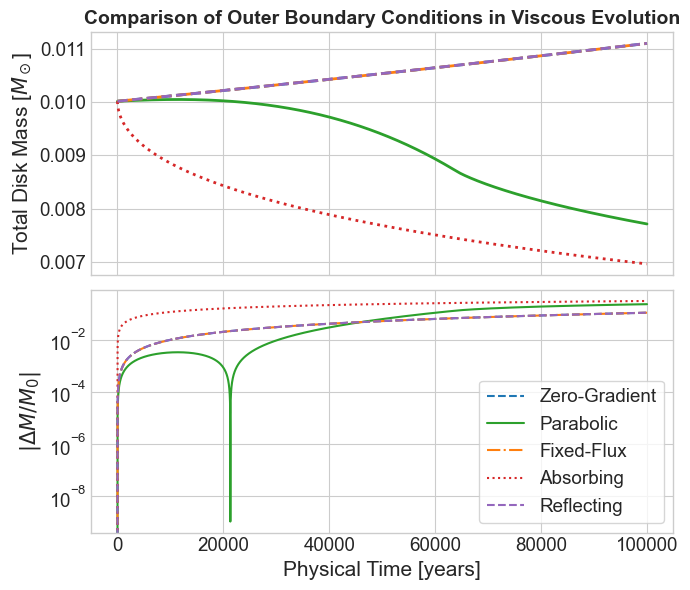

In [17]:
import numpy as np
import matplotlib.pyplot as plt

import os

# current working directory
cwd = os.getcwd()

# if we are NOT inside notebooks, try to find it
if os.path.basename(cwd) != "notebooks":
    # search for a notebooks directory in the current tree
    for root, dirs, files in os.walk(".", topdown=True):
        if "notebooks" in dirs:
            notebooks_path = os.path.join(root, "notebooks")
            os.chdir(notebooks_path)
            print(f"Changed directory to: {notebooks_path}")
            break
    else:
        print("No 'notebooks' directory found. Staying in current directory.")
else:
    print("Already inside notebooks.")


runs = {
    "Zero-Gradient": "mass_conservation_test/mass_test_zero_gradient/LOGS/mass_conservation_100k.dat",
    "Parabolic": "mass_conservation_test/mass_test_parabolic/LOGS/mass_conservation_100k.dat",
    "Fixed-Flux": "mass_conservation_test/mass_test_fixed_flux/LOGS/mass_conservation_100k.dat",
    "Absorbing": "mass_conservation_test/mass_test_absorbing/LOGS/mass_conservation_100k.dat",
    "Reflecting": "mass_conservation_test/mass_test_reflecting/LOGS/mass_conservation_100k.dat"
}

# Stílus beállítása
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

colors = {
    'Zero-Gradient': '#1f77b4', 
    'Parabolic': '#2ca02c', 
    'Fixed-Flux': '#ff7f0e', 
    'Absorbing': '#d62728', 
    'Reflecting': '#9467bd'
}
linestyles = {
    'Zero-Gradient': '--', 
    'Parabolic': '-', 
    'Fixed-Flux': '-.', 
    'Absorbing': ':', 
    'Reflecting': '--'
}

# Alapadat betöltése a kiindulási tömeghez (M_0)
# A parabolic / első futás t=0 tömegét vesszük referenciának
ref_data = np.loadtxt("mass_conservation_test/mass_test_parabolic/LOGS/mass_conservation_100k.dat")
M0 = ref_data[0, 1]

for label, path in runs.items():
    try:
        data = np.loadtxt(path)
        time = data[:, 0]
        mass = data[:, 1]
        
        # Relatív eltérés a kezdeti tömegtől vagy az adott futás saját M0-jától
        # Itt a futás saját t=0 tömegéhez viszonyítjuk a relatív változást
        local_M0 = mass[0]
        rel_diff = np.abs(mass - local_M0) / local_M0
        
        # --- Felső panel: Tömeg evolúció ---
        ax1.plot(time, mass, label=label, color=colors.get(label, 'black'), 
                 linestyle=linestyles.get(label, '-'), lw=2)
        
        # --- Alsó panel: Relatív hiba / változás ---
        ax2.plot(time, rel_diff, label=label, color=colors.get(label, 'black'), 
                 linestyle=linestyles.get(label, '-'), lw=1.5)  # <--- Itt volt a hiányzó label=label!        
    except FileNotFoundError:
        print(f"Warning: File not found for {label} at {path}")

# Felső panel beállításai
ax1.set_ylabel(r'Total Disk Mass [$M_\odot$]', fontsize=15)
ax1.set_title('Comparison of Outer Boundary Conditions in Viscous Evolution', fontsize=14, fontweight='bold')
ax1.tick_params(axis='both', which='major', labelsize=13.5)

# Alsó panel beállításai
ax2.set_yscale('log')
ax2.set_xlabel('Physical Time [years]', fontsize=15)
ax2.set_ylabel(r'$|\Delta M / M_0|$', fontsize=15)
ax2.legend(loc='lower right', frameon=True, fontsize=13.5)
ax2.tick_params(axis='both', which='major', labelsize=13.5)

plt.tight_layout()

# Mentés nagy felbontású PNG-be

output_png = "mass_conservation_test/boundary_conditions_comparison.png"
plt.savefig(output_png, dpi=300)
print(f"Comparison plot successfully saved to: {output_png}")

plt.show()